# Spikecurate

_via regression model_

**author**: laquitainesteeve@gmail.com

**purpose**: train a regression model to classify curate the "good" units (>80% agreement score) amongst the sorted single-units, for the biophysical simulation in the spontaneous regime. 

**tested on**:

* Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz) with RTX 5090 GPU with 40GB VRAM (GPU not needed)

**Method**
- kilosort4's sorting extractor was generated with rtx5090 GPU, so the results slightly change from the original Tesla V100
- a dataset dataframe that contains the sorted single-units (indices), their quality metrics and their quality label ("good" or "bad" units evaluated with our ground truth, columns)

## Setup 

1. Create and activate envs/spikebias.yml

In [29]:
# automatically reload notebook
%load_ext autoreload
%autoreload 2

# import built-in packages
import os
import shutil
import pickle
import copy
import random
import pandas as pd
import spikeinterface as si
import spikeinterface.preprocessing as spre
import spikeinterface.core.template_tools as ttools
from spikeinterface import comparison
from spikeinterface.curation import remove_excess_spikes
from spikeinterface import extract_waveforms
from spikeinterface.postprocessing import compute_principal_components
from spikeinterface.qualitymetrics import compute_quality_metrics as qm
import statsmodels.api as sm
from statsmodels.tools.validation import float_like
import torch
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import seaborn as sns
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import warnings

# silence irrelevant warnings
warnings.filterwarnings("ignore", message="There is no Probe attached to this recording.*")
warnings.filterwarnings("ignore", message="Versions are not the same.*")

# spikeinterface version
print("Spikeinterface", si.__version__)

# set project path
proj_path = "/home/steeve/steeve/epfl/code/spikebias/"
os.chdir(proj_path)

# import custom package
from src.nodes.models.Flc import dataloader
from src.nodes.models.Flc import plotutils as flcplot
from src.nodes.curation import spikecurate
from src.nodes.models.Flc.models import FlcModel # FLC model

# experiment parameters
EXP = "NS"
SORTER = "KS4"


# waveform extraction parameters
FREQ_MIN = 300
REFERENCE = "global"
OPERATOR = "median"
MS_BEFORE = 6
MS_AFTER = 6
LOAD_WE = False
DURATION_SEC = 600          # 10 minutes recording
MAX_SPIKES_PER_UNIT = 500   # max number of spikes used per unit
SEED = 0
N_COMP_PCA = 5              # number of pca components
SPARSE = True
OVERWRITE = True
WE_JOB_KWARGS = dict(n_jobs=20, chunk_duration="1s", progress_bar=True)
job_kwargs = dict(n_jobs=-1, progress_bar=True)

CHUNKS = 80000 # for waveform extractor

# model parameters
model_prms = {"seeds": np.arange(0,100,1), "scale_data": False}

# recording extractor
RECORDING_PATH = "dataset/00_raw/recording_npx_spont/"

# kilosort sorting extractor
SORTING_KS4_PATH = "dataset/01_intermediate/sorting/npx_spont/SortingKS4_10m/"

# ground truth extractors
SORTING_TRUE = "dataset/00_raw/ground_truth_npx_spont"
SORTING_TRUE_10mn = "dataset/00_raw/ground_truth_npx_spont_10m"

# waveform extractors
# WE_PATH = "dataset/01_intermediate/waveforms/npx_spont/SortingKS4_10m/"
WE_SINGLE_U_PATH = "dataset/01_intermediate/waveforms/npx_spont/SortingKS4_10m_single_units"

# unit classification
QUALITY_PATH = "dataset/01_intermediate/analysis/sorting_quality/sorting_quality.csv"

# figure parameters
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6  # 5-7 with Nature neuroscience as reference
plt.rcParams["lines.linewidth"] = 0.5 # typically between 0.5 and 1
plt.rcParams["axes.linewidth"] = 0.5 
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

# figure legend parameters
legend_cfg = {"frameon": False, "handletextpad": 0.5}
tight_layout_cfg = {"pad": 0.001}
LG_FRAMEON = False              # no legend frame

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Spikeinterface 0.100.8


## Load datasets

* Execution time: 27 ms

### Recording extractor

* Execution time: 

In [2]:
%%time

# load and preprocess recording
Recording = si.load_extractor(RECORDING_PATH)
Recording.set_property('location', Recording.get_property('location')[:,:2])
Recording = spre.highpass_filter(Recording, freq_min=FREQ_MIN)
Recording = spre.common_reference(Recording, reference=REFERENCE, operator=OPERATOR)
display(Recording)

CommonReferenceRecording: 384 channels - 40.0kHz - 1 segments - 82,319,958 samples 
                          2,058.00s (34.30 minutes) - float32 dtype - 117.76 GiB

CPU times: user 2.55 ms, sys: 1.97 ms, total: 4.52 ms
Wall time: 4.31 ms


### Ground truth extractor

* Execution time: 

In [4]:
%%time

# load ground truth
SortingTrue = si.load_extractor(SORTING_TRUE)
SortingTrue.frame_slice(start_frame=0, end_frame=Recording.get_sampling_frequency() * DURATION_SEC)
SortingTrue.save(folder=SORTING_TRUE_10mn, overwrite=True)
display(SortingTrue)

NumpyFolderSorting: 1388 units - 1 segments - 40.0kHz

CPU times: user 3.73 ms, sys: 11 ms, total: 14.8 ms
Wall time: 14.5 ms


### Sorting extractor

* Execution time: 20 ms

In [6]:
%%time

# load sorting
Sorting = si.load_extractor(SORTING_KS4_PATH)
Sorting = remove_excess_spikes(Sorting, Recording)
Sorting = Sorting.frame_slice(start_frame=0, end_frame=Recording.get_sampling_frequency() * DURATION_SEC)
display(Sorting)

FrameSliceSorting: 520 units - 1 segments - 40.0kHz

CPU times: user 1.93 ms, sys: 0 ns, total: 1.93 ms
Wall time: 1.68 ms


### Waveform extractor (Sorted units)

* Execution time: 1h24

In [12]:
%%time 

# select sorted single-units amongst single- and multi-units (KSLABEL="good" for kilosort4)
single_unit_ids = Sorting.unit_ids[np.where(Sorting.get_property("KSLabel") == "good")[0]]
Sorting_single_units = Sorting.select_units(unit_ids=single_unit_ids)

# save their waveforms
We_single_u = extract_waveforms(Recording, Sorting_single_units, WE_SINGLE_U_PATH, mode="folder", sparse=SPARSE, ms_before=MS_BEFORE,
                    ms_after=MS_AFTER, max_spikes_per_unit=MAX_SPIKES_PER_UNIT, unit_batch_size=CHUNKS,
                    overwrite=OVERWRITE, seed=SEED, **WE_JOB_KWARGS)


# save waveform PCA data (the extractor is updated)
pca = compute_principal_components(waveform_extractor=We_single_u, n_components=N_COMP_PCA, mode="by_channel_local", **WE_JOB_KWARGS)

extract waveforms shared_memory multi buffer:   0%|          | 0/2058 [00:00<?, ?it/s]

extract waveforms memmap multi buffer:   0%|          | 0/2058 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/184 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/184 [00:00<?, ?it/s]

CPU times: user 44.1 s, sys: 1min 23s, total: 2min 7s
Wall time: 1h 24min


### Single-unit ids and labels (good/gad)

In [27]:
%%time

# label "good" and "bad" sorted single-units to train the classifier
good_unit_ids, bad_unit_ids = dataloader.get_good_and_bad_units(QUALITY_PATH, exp="NS", sorter="KS4")

# report
print("\nSingle-unit ids:", single_unit_ids)
print("\nGood unit ids:", good_unit_ids)
print("\nBad unit ids:", bad_unit_ids)


Single-unit ids: [198 199 213 214 231 240 241 247 252 254 262 269 280 284 286 292 296 297
 299 307 316 318 172 321 166 162  42  48  53  54  58  61  76  83  84  96
 108 109 116 117 121 122 135 142 143 146 152 160 323 328 452 453 455 459
 460 462 465 466 472 473 477 478 479 485 487 451 325 435 342 345 358 385
 389 391 399 401 402 410 411 413 424 426 432 438  26 158 165 183 189 193
 197 201 202 207 211 221 223 227 239 249 250 263 264 270 277 281 283 289
 157 291 149 130  29  40  41  45  55  56  60  66  71  77  81  85  86  90
 102 104 105 110 113 120 126 127 128 140 300 302 304 442 445 446 448 449
 450 458 461 463 469 470 471 475 482 483 484 490 440 429 420 408 308 310
 315 319 333 339 341 346 348 350 365 368 374 380 381 384 386 390 393 396
 398 400 405 371]

Good unit ids: [198 199 213 214 231 240 241 247 252 254 262 269 280 284 286 292 296 297
 299 307 316 318 172 321 166 162  42  48  53  54  58  61  76  83  84  96
 108 109 116 117 121 122 135 142 143 146 152 160 323 328 452 453 455 459

### Unit-tests

In [30]:
%%time

# sanity check units are correct
single_unit_ids_from_file = dataloader.get_sorted_single_unit_ids_from_file(QUALITY_PATH, EXP, SORTER)
assert len(np.intersect1d(single_unit_ids_from_file, single_unit_ids)) == len(single_unit_ids_from_file), "Units are missing or differ"

CPU times: user 5.62 ms, sys: 0 ns, total: 5.62 ms
Wall time: 5.48 ms


## Engineer metrics of cell quality

* Execution time: 2 min

In [21]:
%%time

# engineer a dataset of quality metrics (cols) per cell (rows)
data = dataloader.load_dataset(single_unit_ids, good_unit_ids, bad_unit_ids, Sorting_single_units, SortingTrue, We_single_u, load_qm_if_exists=False, delta_time=1.3, job_kwargs=WE_JOB_KWARGS)


Computing spikeinterface quality metrics:


extract amplitudes:   0%|          | 0/2058 [00:00<?, ?it/s]

  0%|          | 0/184 [00:00<?, ?it/s]

****************** Analysing data completion ***************
Data completion: amplitude_cutoff        184
firing_range            184
firing_rate             184
isi_violations_ratio    184
presence_ratio          184
rp_contamination        184
rp_violations           184
sd_ratio                184
snr                     184
silhouette              182
dtype: int64
quality metrics are: Index(['amplitude_cutoff', 'firing_range', 'firing_rate',
       'isi_violations_ratio', 'presence_ratio', 'rp_contamination',
       'rp_violations', 'sd_ratio', 'snr', 'silhouette'],
      dtype='object')

Extracing spike amplitudes:


extract amplitudes:   0%|          | 0/2058 [00:00<?, ?it/s]


Calculating MAD ratios:

Quality metrics used: 
Index(['amplitude_cutoff', 'firing_range', 'firing_rate',
       'isi_violations_ratio', 'presence_ratio', 'rp_contamination',
       'rp_violations', 'sd_ratio', 'snr', 'silhouette', 'mad_ratio'],
      dtype='object')
2026-08-27 19:19:32,182 - root - dataloader.py - load_dataset - INFO - nb of units before filtering units with inf feature: 184
2026-08-27 19:19:32,183 - root - dataloader.py - load_dataset - INFO - nb of units after clearning missing data: 184
CPU times: user 15.2 s, sys: 6.03 s, total: 21.2 s
Wall time: 1min 26s


In [24]:
%%time 

# measure correlations between features (less is better)
data["dataset"].corr()

CPU times: user 273 µs, sys: 0 ns, total: 273 µs
Wall time: 377 µs


,amplitude_cutoff,firing_range,firing_rate,isi_violations_ratio,rp_contamination,rp_violations,sd_ratio,snr,silhouette,mad_ratio,quality_label
amplitude_cutoff,1.000000,-0.151497,-0.151771,0.292512,0.058562,-0.034075,0.448366,0.592390,0.377775,0.260285,-0.107790
firing_range,-0.151497,1.000000,0.996525,-0.081202,0.206018,0.442963,-0.097001,-0.216860,-0.271632,0.018511,0.026902
firing_rate,-0.151771,0.996525,1.000000,-0.080729,0.198882,0.429786,-0.113905,-0.209046,-0.248838,-0.002453,0.066000
isi_violations_ratio,0.292512,-0.081202,-0.080729,1.000000,0.436161,0.182912,0.222876,0.288762,0.175332,0.066345,0.023906
rp_contamination,0.058562,0.206018,0.198882,0.436161,1.000000,0.555389,0.076438,-0.032632,-0.037552,0.079930,-0.015572
rp_violations,-0.034075,0.442963,0.429786,0.182912,0.555389,1.000000,0.000085,-0.078243,-0.105091,0.014258,-0.043278
sd_ratio,0.448366,-0.097001,-0.113905,0.222876,0.076438,0.000085,1.000000,0.418690,0.066979,0.882160,-0.297311
snr,0.592390,-0.216860,-0.209046,0.288762,-0.032632,-0.078243,0.418690,1.000000,0.548289,0.100845,0.217650
silhouette,0.377775,-0.271632,-0.248838,0.175332,-0.037552,-0.105091,0.066979,0.548289,1.000000,-0.127304,0.144787
mad_ratio,0.260285,0.018511,-0.002453,0.066345,0.079930,0.014258,0.882160,0.100845,-0.127304,1.000000,-0.441525


## Model: train/detect >80% accurate units

quality metrics are: Index(['amplitude_cutoff', 'firing_range', 'firing_rate',
       'isi_violations_ratio', 'presence_ratio', 'rp_contamination',
       'rp_violations', 'sd_ratio', 'snr', 'silhouette'],
      dtype='object')

CPU times: user 1.09 s, sys: 0 ns, total: 1.09 s
Wall time: 1.09 s


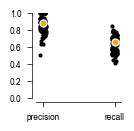

In [23]:
%%time

# instantiate the model
flcmodel = FlcModel(data["predictors"])

# train & eval. w/ cross-val.
results = flcmodel.evaluate(data["dataset"], **model_prms)

# plot
fig, ax = plt.subplots(1, 1, figsize=(1.1, 1.1))
ax = flcplot.plot(ax, results["metric_data"])

### Train & eval

* z-scoring the features marginally changed the results. So we used the raw data, to produce more interpretable weights.

#### Z-scored


precision:
median: 0.8571428571428571
std: 0.10613961487772469
95% CI: 0.02080336451603404

recall:
median r2: 0.6594202898550725
std r2: 0.12667146190124934
95% CI: 0.024827606532644868


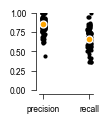

In [25]:
# parameters
seeds = np.arange(0, 100, 1)

# curate dataset
dataset_c = copy.copy(data["dataset"])

# (10s) evaluate
precisions, recalls = spikecurate.train_test_eval(flcmodel.formula, dataset_c, seeds, scale_data=True)

#### Raw


precision:
median: 0.875
std: 0.0914209857705335
95% CI: 0.017918513211024563

recall:
median r2: 0.6594202898550725
std r2: 0.08928784269367666
95% CI: 0.017500417167960625


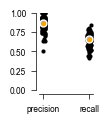

In [26]:
# curate dataset
dataset_c = copy.copy(data["dataset"])

# (10s) evaluate
precisions, recalls = spikecurate.train_test_eval(flcmodel.formula, dataset_c, seeds, scale_data=False)